# Data analysis notebook

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(Path().resolve().parent))

from config import RAW_DATA_DIR, PROCESSED_DATA_DIR, STATIONS

In [2]:
import json
import requests

from datetime import datetime, timedelta, timezone
from pprint import pprint

import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Loading data

In [3]:
milan_lampugnano_df = pd.read_csv(PROCESSED_DATA_DIR / 'milan_lampugnano_departures.csv')
genoa_principe_df = pd.read_csv(PROCESSED_DATA_DIR / 'genoa_principe_departures.csv')

In [4]:
milan_lampugnano_df.head()

,id,bus_code,direction,name,deviation_seconds,updated_at,scheduled_timestamp,our_snapshot_time
0,23c8dea6-ab2f-429c-ba95-545b24835042,N456,"Lublin, Bus Station Lublin",Lublin - Milan - Marseille,2859.0,2026-05-20T16:12:41Z,2026-05-20T16:35:00Z,2026-05-20T18:18:17
1,279429f3-5d1a-4c7b-a7f8-b2d520720fc8,518,Como,Naples - Milan - Como,0.0,2026-05-20T04:48:55Z,2026-05-20T17:25:00Z,2026-05-20T18:18:17
2,f54c0343-266b-4ebc-804e-0228733d2e5a,423,Turin (Vittorio Emanuele),Turin - Ferrara,263.0,2026-05-20T16:18:27Z,2026-05-20T17:30:00Z,2026-05-20T18:18:17
3,afeed613-2e47-4b8a-865d-ea644648ff3d,N836,Amsterdam Sloterdijk,Amsterdam - Brussels - Luxemburg - Milan,NaN,NaN,2026-05-20T17:40:00Z,2026-05-20T18:18:17
4,7f008d8a-46b9-4a06-9fa6-4a01f7294883,CIT3197,Milan (Malpensa Airport Terminal 1),Standard,NaN,NaN,2026-05-20T17:45:00Z,2026-05-20T18:18:17


In [5]:
genoa_principe_df.head()

,id,bus_code,direction,name,deviation_seconds,updated_at,scheduled_timestamp,our_snapshot_time
0,4a8a8865-2806-4f83-869e-bda601b25a60,501,Turin (Vittorio Emanuele),Turin - Naples,0.0,2026-05-20T16:12:24Z,2026-05-20T17:55:00Z,2026-05-20T18:18:17
1,c36a991e-02a2-4da2-b7b0-6a0bf3f1979f,N758,Barcelona (Bus Terminal Nord),Florence - Barcelona,0.0,2026-05-20T16:16:23Z,2026-05-20T19:25:00Z,2026-05-20T18:18:17
2,fb971887-fb5f-4f70-9ee3-51f98e2df1f0,N177,Düsseldorf central bus station,Düsseldorf - Genoa,NaN,NaN,2026-05-20T19:30:00Z,2026-05-20T18:18:17
3,0aa24a02-20c3-4546-a0da-7204720f792e,N728,Munich central bus station,Munich/Genoa - Barcelona,0.0,2026-05-20T06:52:32Z,2026-05-20T21:05:00Z,2026-05-20T18:18:17
4,3e59c7ef-b056-405d-a477-9fe1df21eeb9,N504,Perugia (Piazza Partigiani),Geneva - Turin - Perugia,0.0,2026-05-20T16:09:23Z,2026-05-20T21:20:00Z,2026-05-20T18:18:17


Concatenate these two dataframes:

In [6]:
milan_lampugnano_df['station'] = 'Milan Lampugnano'
genoa_principe_df['station'] = 'Genoa Principe'

df = pd.concat([milan_lampugnano_df, genoa_principe_df], ignore_index=True)

In [ ]:
df.head()

In [ ]:
df['updated_at'].replace('Z', '', regex=True, inplace=False)

In [ ]:
df['deviation_minutes'] = df['deviation_seconds'] / 60

In [ ]:
df['deviation_minutes'].describe()

In [ ]:
df['deviation_minutes'].hist(bins=50)
plt.xlabel('Delay [minutes]')
plt.ylabel('Frequency')
plt.title('Distribution of Flixbus Delays')
plt.show()

This isn't a good measure because we are snapshotting all the time - so the same delay appears for a finite snapshot range/or until the bus gets back to the schedule. It might make sense that for EACH ride I check the delay, how it changes with time, or at a specific point - idk, when it arrives at the station or something like this.

In [ ]:
df.groupby('station')['deviation_minutes'].describe()

In [ ]:
df.groupby('bus_code')['deviation_minutes'].describe()

In [ ]:
df.groupby('bus_code')['deviation_minutes'].hist(bins=10)
plt.xlabel('Delay [minutes]')
plt.ylabel('Frequency')
plt.title('Distribution of Flixbus Delays')
plt.show()

## Cleaning

Let's take care of the date formatting

In [ ]:
df.head()

Format the time uniformly:

In [7]:
df['our_snapshot_time'] = pd.to_datetime(df['our_snapshot_time'])
df['scheduled_timestamp'] = pd.to_datetime(df['scheduled_timestamp'])
df['updated_at'] = pd.to_datetime(df['updated_at'])

In [8]:
df.head()

,id,bus_code,direction,name,deviation_seconds,updated_at,scheduled_timestamp,our_snapshot_time,station
0,23c8dea6-ab2f-429c-ba95-545b24835042,N456,"Lublin, Bus Station Lublin",Lublin - Milan - Marseille,2859.0,2026-05-20 16:12:41+00:00,2026-05-20 16:35:00+00:00,2026-05-20 18:18:17,Milan Lampugnano
1,279429f3-5d1a-4c7b-a7f8-b2d520720fc8,518,Como,Naples - Milan - Como,0.0,2026-05-20 04:48:55+00:00,2026-05-20 17:25:00+00:00,2026-05-20 18:18:17,Milan Lampugnano
2,f54c0343-266b-4ebc-804e-0228733d2e5a,423,Turin (Vittorio Emanuele),Turin - Ferrara,263.0,2026-05-20 16:18:27+00:00,2026-05-20 17:30:00+00:00,2026-05-20 18:18:17,Milan Lampugnano
3,afeed613-2e47-4b8a-865d-ea644648ff3d,N836,Amsterdam Sloterdijk,Amsterdam - Brussels - Luxemburg - Milan,NaN,NaT,2026-05-20 17:40:00+00:00,2026-05-20 18:18:17,Milan Lampugnano
4,7f008d8a-46b9-4a06-9fa6-4a01f7294883,CIT3197,Milan (Malpensa Airport Terminal 1),Standard,NaN,NaT,2026-05-20 17:45:00+00:00,2026-05-20 18:18:17,Milan Lampugnano


### How to use df.resample

resample does a similar thing like groupby(). Here is the basic usage:

In [9]:
df = df.set_index('our_snapshot_time') # now the data is sorted by the time we took the snapshot of the data, which is when we observed the delay. This allows us to analyze how delays evolve over time leading up to the scheduled departure time.

In [10]:
df.head()

,id,bus_code,direction,name,deviation_seconds,updated_at,scheduled_timestamp,station
our_snapshot_time,,,,,,,,
2026-05-20 18:18:17,23c8dea6-ab2f-429c-ba95-545b24835042,N456,"Lublin, Bus Station Lublin",Lublin - Milan - Marseille,2859.0,2026-05-20 16:12:41+00:00,2026-05-20 16:35:00+00:00,Milan Lampugnano
2026-05-20 18:18:17,279429f3-5d1a-4c7b-a7f8-b2d520720fc8,518,Como,Naples - Milan - Como,0.0,2026-05-20 04:48:55+00:00,2026-05-20 17:25:00+00:00,Milan Lampugnano
2026-05-20 18:18:17,f54c0343-266b-4ebc-804e-0228733d2e5a,423,Turin (Vittorio Emanuele),Turin - Ferrara,263.0,2026-05-20 16:18:27+00:00,2026-05-20 17:30:00+00:00,Milan Lampugnano
2026-05-20 18:18:17,afeed613-2e47-4b8a-865d-ea644648ff3d,N836,Amsterdam Sloterdijk,Amsterdam - Brussels - Luxemburg - Milan,NaN,NaT,2026-05-20 17:40:00+00:00,Milan Lampugnano
2026-05-20 18:18:17,7f008d8a-46b9-4a06-9fa6-4a01f7294883,CIT3197,Milan (Malpensa Airport Terminal 1),Standard,NaN,NaT,2026-05-20 17:45:00+00:00,Milan Lampugnano


Resample hourly:

In [15]:
hourly = df.resample("1h")['deviation_seconds']

In [25]:
df.resample("1h").size()

our_snapshot_time
2026-05-20 18:00:00    176
2026-05-20 19:00:00    199
2026-05-20 20:00:00    158
2026-05-20 21:00:00    152
2026-05-20 22:00:00    129
2026-05-20 23:00:00    157
2026-05-21 00:00:00    172
2026-05-21 01:00:00    219
2026-05-21 02:00:00    261
2026-05-21 03:00:00    334
2026-05-21 04:00:00    332
2026-05-21 05:00:00    361
2026-05-21 06:00:00    362
2026-05-21 07:00:00    356
2026-05-21 08:00:00    334
2026-05-21 09:00:00    358
2026-05-21 10:00:00    356
2026-05-21 11:00:00    347
2026-05-21 12:00:00    343
2026-05-21 13:00:00    350
2026-05-21 14:00:00    221
Freq: h, dtype: int64

In [26]:
hourly.size()

our_snapshot_time
2026-05-20 18:00:00    176
2026-05-20 19:00:00    199
2026-05-20 20:00:00    158
2026-05-20 21:00:00    152
2026-05-20 22:00:00    129
2026-05-20 23:00:00    157
2026-05-21 00:00:00    172
2026-05-21 01:00:00    219
2026-05-21 02:00:00    261
2026-05-21 03:00:00    334
2026-05-21 04:00:00    332
2026-05-21 05:00:00    361
2026-05-21 06:00:00    362
2026-05-21 07:00:00    356
2026-05-21 08:00:00    334
2026-05-21 09:00:00    358
2026-05-21 10:00:00    356
2026-05-21 11:00:00    347
2026-05-21 12:00:00    343
2026-05-21 13:00:00    350
2026-05-21 14:00:00    221
Freq: h, Name: deviation_seconds, dtype: int64

In [23]:
hourly.mean()

our_snapshot_time
2026-05-20 18:00:00     69.232143
2026-05-20 19:00:00     24.105263
2026-05-20 20:00:00     77.838095
2026-05-20 21:00:00    229.375000
2026-05-20 22:00:00    290.301887
2026-05-20 23:00:00    344.495327
2026-05-21 00:00:00    471.429907
2026-05-21 01:00:00    390.715517
2026-05-21 02:00:00    595.000000
2026-05-21 03:00:00    642.939850
2026-05-21 04:00:00    787.310345
2026-05-21 05:00:00    835.460938
2026-05-21 06:00:00    460.657143
2026-05-21 07:00:00    609.355705
2026-05-21 08:00:00    460.386364
2026-05-21 09:00:00    385.935484
2026-05-21 10:00:00    290.723529
2026-05-21 11:00:00    224.698718
2026-05-21 12:00:00    228.778571
2026-05-21 13:00:00    133.688000
2026-05-21 14:00:00    156.768293
Freq: h, Name: deviation_seconds, dtype: float64

Note that df.resample('1h').mean() doesn't work if we include THE WHOLE DATAFRAME. Because then pandas tries to get a mean of all the columns, including string columns like name, direction etc.

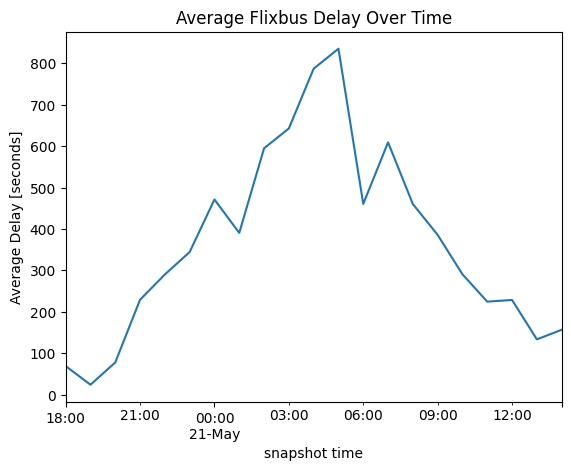

In [22]:
hourly.mean().plot()
plt.xlabel('snapshot time')
plt.ylabel('Average Delay [seconds]')
plt.title('Average Flixbus Delay Over Time')
plt.show()

However, this plot and these information do not make sense, since we are averaging over a couple of snapshots, and also different rides. 
The information have sense if we fix a ride (using the unique ride ID or the name of the line (N458 for example) WITH THE SAME DESTINATION), and then, for each snapshot time, check the delay.